# HarvestStat Data Profiling - Ethiopia

In [1]:
import glob
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import numpy as np
import pandas as pd
import geopandas as gpd
from tools import retreive_fdw_data, save_npz, PrintAdminUnits, PlotAdminShapes
from tools import FDW_PD_Sweeper, FDW_PD_AvalTable, FDW_PD_Compiling, FDW_PD_ValidateFnidName
from tools import FDW_PD_CreateAdminLink, FDW_PD_RatioAdminLink, FDW_PD_ConnectAdminLink
from tools import product_name_mapping, FDW_PD_CaliSeasonYear, FDW_PD_MergeCropProductionSystem
from tools_graphic import PlotBarProduction, PlotLinePAY
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
pd.options.mode.chained_assignment = None

In [2]:
# Set loading parameters ------------------------ #
country_name = 'Ethiopia'
country_iso2 = 'ET'
use_api_data = False
requires_authentication = False
# ----------------------------------------------- #

# Load FDW data -------------------------------- #
df = retreive_fdw_data(country_name, country_iso2, use_api_data, requires_authentication)
# ----------------------------------------------- #

Data is loaded from the local file.
../data/crop_raw_data/adm_crop_data_raw_ET.csv is loaded.


In [3]:
#pd.set_option('display.max_columns', None)
#df.loc[(df.fnid=='ET2007R20411')&(df['product']=='Sorghum'),['value','indicator','period_date']]

In [4]:
# Load FEWS NET administrative boundaries ------- #
epsg = 'EPSG:32637' # Ethiopia
fn_shapes = sorted(glob.glob(f"../data/shapefile/fewsnet/{country_iso2}_Crop_Level?_????.shp"))
shape_all = []
for fn in fn_shapes:
    name = fn[-23:-4]
    exec('%s = gpd.read_file("%s").to_crs("%s")' % (name, fn, epsg))
    exec('%s["area"] = %s["geometry"].area/10**6' % (name, name))
    exec('shape_all.append(%s)' % (name))
shape_all = pd.concat(shape_all, axis=0).reset_index(drop=True)
# PrintAdminUnits(shape_all)
# ----------------------------------------------- #

In [5]:
df.loc[((df.admin_2=='Kemashi')&(pd.to_datetime(df.period_date).dt.to_period('Y')=='2000'))
,['fnid','admin_2','value','indicator','product']]

,fnid,admin_2,value,indicator,product
10361,ET2000R20604,Kemashi,NaN,Area Harvested,Beans (White)
10362,ET2000R20604,Kemashi,NaN,Area Harvested,Groundnuts (In Shell)
10363,ET2000R20604,Kemashi,NaN,Area Harvested,Sesame Seed
10364,ET2000R20604,Kemashi,NaN,Area Harvested,Sorghum
10386,ET2000R20604,Kemashi,30.00,Area Planted,Groundnuts (In Shell)
10387,ET2000R20604,Kemashi,1630.00,Area Planted,Sesame Seed
10388,ET2000R20604,Kemashi,640.00,Area Planted,Beans (White)
10389,ET2000R20604,Kemashi,9880.00,Area Planted,Sorghum
10411,ET2000R20604,Kemashi,12932.00,Quantity Produced,Sorghum
10412,ET2000R20604,Kemashi,18.00,Quantity Produced,Groundnuts (In Shell)


In [6]:
# Manual Pre-processing before Sweeping --------- #
# 1. Default setting
# a.1) None-type crop production system
df.loc[df['crop_production_system'].isna(), 'crop_production_system'] = 'none'
df.loc[df['crop_production_system'] == '', 'crop_production_system'] = 'none'
# a.2) Early in the record the catch-all crop production system is 'all' rather than none. Make these to none-type
df.loc[df['crop_production_system'] == 'all', 'crop_production_system'] = 'none'
# b) None-type population group
df.loc[df['population_group'].isna(), 'population_group'] = 'none'
df.loc[df['population_group'] == '', 'population_group'] = 'none'
# ----------------------------------------------- #

#Drop the blank (nan) rows that are duplicates of rows that do have data
df=df[np.isfinite(df.value)]
#limit the data to admin 2 resolution, note that this drops the Belg data
df=df.dropna(subset=['admin_2'])
rows = ['fnid','season_year', 'product','indicator','crop_production_system']

#rename the crop data for Maize Grain (Fresh) to Maize (corn)
df.loc[(df['product'] == 'Maize Grain (Fresh)'),'product'] = 'Maize (Corn)'

#Barley (White) only exists in years/areas where Barley (Unspecified) does not exist. Rename to a single Barley (Unspecified) class
df.loc[(df['product'] == 'Barley (White)'),'product'] = 'Barley (Unspecified)'

## Drop values that don't include both area and production

#drop observations from Kemashi in 2000. The only crop with data (sorghum) is missing ha, although it exists in the source doc
df = df[~((df.fnid=='ET1996R20604')&(pd.to_datetime(df.period_date).dt.to_period('Y')=='2000'))]


#replace a mistyped value of 44000 with 440 (confirmed with sourcr docs)
#df.loc[((df.fnid=='ET1996R20724')&(df['product']=='Maize (Corn)')&
#    (df['indicator']=='Area Planted')&(df['status']=='Collected')&
#    (pd.to_datetime(df.period_date).dt.to_period('Y')=='2000')),'value']=440



In [7]:

# FDW Production Data Inspection ---------------- #
df, df_raw = FDW_PD_Sweeper(df)
table_dict = FDW_PD_AvalTable(df, shape_all)
# ----------------------------------------------- #


# FEWS NET Shapefile comparison ----------------- #
shape_used = pd.concat([ET_Crop_Level2_1994,ET_Crop_Level2_1996,ET_Crop_Level2_2000,ET_Crop_Level2_2003,
                        ET_Crop_Level2_2007,ET_Crop_Level2_2011,ET_Crop_Level2_2016,ET_Crop_Level2_2019,
                        ET_Crop_Level2_2020,ET_Crop_Level2_2021,ET_Crop_Level2_2023], axis=0)
PlotAdminShapes(shape_used, label=True)
# ----------------------------------------------- #

- Remove missing records ---------------------- #
Orignial data points: 55,723
Removed 3 "Missing Value" points
19,913/19,913 "Area Planted" points are retained.
18,076/18,076 "Quantity Produced" points are retained.
17,731/17,734 "Yield" points are retained.
Current data points: 55,720

- Minor changes are applied ------------------- #

- Basic information --------------------------- #
Data period: 1994 - 2022
50 grain types are found: Banana (unspecified), Barley (Unspecified), Beans (Red), Beans (White), Beans (mixed), Beet, Cabbage (Unspecified), Carrots, Chat, Chick Peas, Chili pepper (Unspecified), Coffee (unspecified), Desi chick pea, Enset, Ethiopian cabbage, Fava bean, Fenugreek, Field Peas, Garlic, Gibto, Grass Pea, Green Peppers, Groundnuts (In Shell), Hops, Kabuli chick pea, Lentils, Lettuce (Unspecified), Linseed (unspecified), Maize (Corn), Millet (Finger), Mixed Teff, Mung bean (unspecified), Neug, Oats (Unspecified), Onions, Potato (unspecified), Rape, Rice (Paddy), Saf

- Ethiopia crop seasonal calendar

<img src="https://fews.net/sites/default/files/styles/large_width_880/public/2023-03/seasonal-calendar-ethiopia.png?itok=xWM8Nlr6"  width=900><br>

<!-- <img src="https://www.fao.org/giews/countrybrief/country/ETH/graphics/1_2023-06-15.jpg"  width=900> -->

- comparison of boundaries

<img src="../figures/ET_admin_shapes.png"  width=900>

- In Ethiopia, basd on the FEWS NET data, we have the following unit sets: 1994R2, 1996R2, 2000R2, 2003R2, 2007R2, 2011R2, 2016R2, 2019R2, 2020R2, and 2021R2



In [8]:
# Define the latest shapefile ------------------- #
latest_level = 2
shape_latest = ET_Crop_Level2_2021.copy().to_crs('epsg:4326')
# ----------------------------------------------- #

# Validation of FNIDs and Names ----------------- #
df = FDW_PD_ValidateFnidName(df, shape_used, shape_latest)
# ----------------------------------------------- #

# FDW Production Data Compiling ----------------- #
area, prod = FDW_PD_Compiling(df, shape_used)
area_all, prod_all = area.copy(), prod.copy()
mdx_pss = area.columns.droplevel([0,1]).unique()
# ----------------------------------------------- #

In [9]:
#Prevent imbalanced dataframes
prod[area!=area] = np.nan #set locations with prod but no area data to nan
area[prod!=prod] = np.nan #set locations with area but no prod data to nan

In [10]:
# Link admin boundaries ------------------------- #
link_1994, over_1994 = FDW_PD_CreateAdminLink(ET_Crop_Level2_1994, ET_Crop_Level2_2021, 'ADMIN2', 'ADMIN2', prod, epsg)
link_1996, over_1996 = FDW_PD_CreateAdminLink(ET_Crop_Level2_1996, ET_Crop_Level2_2021, 'ADMIN2', 'ADMIN2', prod, epsg)
link_2000, over_2000 = FDW_PD_CreateAdminLink(ET_Crop_Level2_2000, ET_Crop_Level2_2021, 'ADMIN2', 'ADMIN2', prod, epsg)
link_2003, over_2003 = FDW_PD_CreateAdminLink(ET_Crop_Level2_2003, ET_Crop_Level2_2021, 'ADMIN2', 'ADMIN2', prod, epsg)
link_2007, over_2007 = FDW_PD_CreateAdminLink(ET_Crop_Level2_2007, ET_Crop_Level2_2021, 'ADMIN2', 'ADMIN2', prod, epsg)
link_2011, over_2011 = FDW_PD_CreateAdminLink(ET_Crop_Level2_2011, ET_Crop_Level2_2021, 'ADMIN2', 'ADMIN2', prod, epsg)
link_2016, over_2016 = FDW_PD_CreateAdminLink(ET_Crop_Level2_2016, ET_Crop_Level2_2021, 'ADMIN2', 'ADMIN2', prod, epsg)
link_2019, over_2019 = FDW_PD_CreateAdminLink(ET_Crop_Level2_2019, ET_Crop_Level2_2021, 'ADMIN2', 'ADMIN2', prod, epsg)
link_2020, over_2020 = FDW_PD_CreateAdminLink(ET_Crop_Level2_2020, ET_Crop_Level2_2021, 'ADMIN2', 'ADMIN2', prod, epsg)

# Crop specific ratios
link_ratio_1994 = FDW_PD_RatioAdminLink(link_1994, prod, over_1994, mdx_pss)
link_ratio_1996 = FDW_PD_RatioAdminLink(link_1996, prod, over_1996, mdx_pss)
link_ratio_2000 = FDW_PD_RatioAdminLink(link_2000, prod, over_2000, mdx_pss)
link_ratio_2003 = FDW_PD_RatioAdminLink(link_2003, prod, over_2003, mdx_pss)
link_ratio_2007 = FDW_PD_RatioAdminLink(link_2007, prod, over_2007, mdx_pss)
link_ratio_2011 = FDW_PD_RatioAdminLink(link_2011, prod, over_2011, mdx_pss)
link_ratio_2016 = FDW_PD_RatioAdminLink(link_2016, prod, over_2016, mdx_pss)
link_ratio_2019 = FDW_PD_RatioAdminLink(link_2019, prod, over_2019, mdx_pss)
link_ratio_2020 = FDW_PD_RatioAdminLink(link_2020, prod, over_2020, mdx_pss)

# Merge link_ratio
assert link_ratio_1994.keys() == link_ratio_2020.keys()
assert link_ratio_1996.keys() == link_ratio_2020.keys()
assert link_ratio_2000.keys() == link_ratio_2020.keys()
assert link_ratio_2003.keys() == link_ratio_2020.keys()
assert link_ratio_2007.keys() == link_ratio_2020.keys()
assert link_ratio_2011.keys() == link_ratio_2020.keys()
assert link_ratio_2016.keys() == link_ratio_2020.keys()
assert link_ratio_2019.keys() == link_ratio_2020.keys()

link_merged = [link_ratio_1994, link_ratio_1996,link_ratio_2000,link_ratio_2003,link_ratio_2007,link_ratio_2011,
              link_ratio_2016,link_ratio_2019,link_ratio_2020]
fnids_new = list(link_merged[0].keys())
link_ratio = dict()
for fnid in fnids_new:
    container = []
    for link in link_merged:
        container.append(link[fnid])
    link_ratio[fnid] = pd.concat(container, axis=1)
# Add current unit to link_ratio
for fnid_new in link_ratio.keys():
    link_ratio[fnid_new][fnid_new] = 1.0
    link_ratio[fnid_new] = link_ratio[fnid_new].sort_index(axis=1, ascending=False)
# Connect data with AdminLink
area_new, prod_new = FDW_PD_ConnectAdminLink(link_ratio, area, prod, validation=False)
# ----------------------------------------------- #


CBR is considered for 'ET1994R20404' as no record found in: ['ET2021R20425']
CBR is considered for 'ET1994R20304' as no record found in: ['ET2021R20312']
CBR is considered for 'ET1994R20318' as no record found in: ['ET2021R20605']
CBR is considered for 'ET1994R20701' as no record found in: ['ET2021R20728']
CBR is considered for 'ET1994R21401' as no record found in: ['ET2021R21401']
CBR is considered for 'ET1994R20314' as no record found in: ['ET2021R20314']
CBR is considered for 'ET1994R20403' as no record found in: ['ET2021R20426']
CBR is considered for 'ET1996R20403' as no record found in: ['ET2021R20426']
CBR is considered for 'ET1996R20404' as no record found in: ['ET2021R20425']
CBR is considered for 'ET1996R20304' as no record found in: ['ET2021R20312']
CBR is considered for 'ET1996R20701' as no record found in: ['ET2021R20728']
CBR is considered for 'ET1996R21401' as no record found in: ['ET2021R21401']
CBR is considered for 'ET1996R20314' as no record found in: ['ET2021R20314']

CBR is considered for 'ET2001A20508' as no record found in: ['ET2014A20508']
CBR is considered for 'ET2001A20503' as no record found in: ['ET2014A20503']
CBR is considered for 'ET2001A20504' as no record found in: ['ET2014A20504']
CBR is considered for 'ET2001A20506' as no record found in: ['ET2014A20506']
CBR is considered for 'ET2001A20505' as no record found in: ['ET2014A20505']
CBR is considered for 'ET2001A20507' as no record found in: ['ET2014A20507']
CBR is considered for 'ET2001A20202' as no record found in: ['ET2014A20202']
CBR is considered for 'ET2001A20204' as no record found in: ['ET2014A20204']
CBR is considered for 'ET2001A20608' as no record found in: ['ET2014A20605']


CBR is considered for 'ET2001A20205' as no record found in: ['ET2014A20205']
CBR is considered for 'ET2001A21410' as no record found in: ['ET2014A21410']


CBR is considered for 'ET2003A20508' as no record found in: ['ET2014A20508']
CBR is considered for 'ET2003A20503' as no record found in: ['ET2014A20503']
CBR is considered for 'ET2003A20504' as no record found in: ['ET2014A20504']
CBR is considered for 'ET2003A20506' as no record found in: ['ET2014A20506']
CBR is considered for 'ET2003A20505' as no record found in: ['ET2014A20505']
CBR is considered for 'ET2003A20507' as no record found in: ['ET2014A20507']
CBR is considered for 'ET2003A20202' as no record found in: ['ET2014A20202']
CBR is considered for 'ET2003A20204' as no record found in: ['ET2014A20204']
CBR is considered for 'ET2003A20608' as no record found in: ['ET2014A20605']
CBR is considered for 'ET2003A20205' as no record found in: ['ET2014A20205']
CBR is considered for 'ET2003A21410' as no record found in: ['ET2014A21410']


CBR is considered for 'ET2007A20508' as no record found in: ['ET2014A20508']
CBR is considered for 'ET2007A20503' as no record found in: ['ET2014A20503']
CBR is considered for 'ET2007A20504' as no record found in: ['ET2014A20504']
CBR is considered for 'ET2007A20506' as no record found in: ['ET2014A20506']
CBR is considered for 'ET2007A20505' as no record found in: ['ET2014A20505']
CBR is considered for 'ET2007A20507' as no record found in: ['ET2014A20507']
CBR is considered for 'ET2007A20202' as no record found in: ['ET2014A20202']
CBR is considered for 'ET2007A20204' as no record found in: ['ET2014A20204']
CBR is considered for 'ET2007A20608' as no record found in: ['ET2014A20605']
CBR is considered for 'ET2007A20205' as no record found in: ['ET2014A20205']
CBR is considered for 'ET2007A21410' as no record found in: ['ET2014A21410']


CBR is considered for 'ET2008A20508' as no record found in: ['ET2014A20508']
CBR is considered for 'ET2008A20503' as no record found in: ['ET2014A20503']
CBR is considered for 'ET2008A20504' as no record found in: ['ET2014A20504']
CBR is considered for 'ET2008A20506' as no record found in: ['ET2014A20506']
CBR is considered for 'ET2008A20505' as no record found in: ['ET2014A20505']
CBR is considered for 'ET2008A20507' as no record found in: ['ET2014A20507']
CBR is considered for 'ET2008A20202' as no record found in: ['ET2014A20202']
CBR is considered for 'ET2008A20204' as no record found in: ['ET2014A20204']
CBR is considered for 'ET2008A20605' as no record found in: ['ET2014A20605']
CBR is considered for 'ET2008A20205' as no record found in: ['ET2014A20205']


CBR is considered for 'ET2008A21410' as no record found in: ['ET2014A21410']


In [11]:
# Manual correction ----------------------------- #
crop_new = prod_new/area_new
# ----------------------------------------------- #

# Complete long format DataFrame ---------------- #
df_area = area_new.T.stack().rename('value').reset_index()
df_area['indicator'] = 'area'
df_prod = prod_new.T.stack().rename('value').reset_index()
df_prod['indicator'] = 'production'
df_yield = crop_new.T.stack().rename('value').reset_index()
df_yield['indicator'] = 'yield'
stack = pd.concat([df_area, df_prod, df_yield], axis=0)
# Add "planting year"
cols = ['season_name','product','crop_production_system','planting_month','harvest_year','harvest_month','planting_year']
season_table = df[cols].drop_duplicates()
stack = stack.merge(season_table, on=cols[:-1])
# Add country and admin names
stack = stack.merge(df[['fnid','country','country_code','admin_1','admin_2']].drop_duplicates(), on='fnid', how='inner')
names = [
    'fnid','country','country_code','admin_1','admin_2','name',
    'product','season_name','planting_year','planting_month','harvest_year','harvest_month',
    'crop_production_system','indicator','value'
]
stack = stack[names]
# ----------------------------------------------- #

# Final Processing ------------------------------ #
# Product name mapping
stack = product_name_mapping(stack, list_except=None)
# Calibration of crop calendar using External Season Calendar (ESC)
esc = pd.read_csv('../data/crop_calendar/external_season_calendar.csv')
stack, link_ratio = FDW_PD_CaliSeasonYear(stack, esc, link_ratio=None)
# None admin names
stack.loc[stack['admin_1'].isna(), 'admin_1'] = 'none'
stack.loc[stack['admin_2'].isna(), 'admin_2'] = 'none'
# ----------------------------------------------- #

# Save data
fn_out = '../data/crop/adm_crop_production_ET.csv'
stack.to_csv(fn_out); print(f'{fn_out} is saved.')
save_npz('../data/crop/adm_crop_production_ET_ratio.npz', link_ratio)

All [country, season_name] are in the external season calendar.
../data/crop/adm_crop_production_ET.csv is saved.
../data/crop/adm_crop_production_ET_ratio.npz is saved.


# Visualization of production data

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

def PlotBarProduction(df, year, footnote, fn_save=None):
    # Filtering and preparing data
    indicator_exist = df['indicator'].unique()
    indicator_exist = indicator_exist[~np.isin(indicator_exist, 'yield')]
    table = df.pivot_table(
        index='year',          
        columns=['fnid','country','name','product','season_name','harvest_month','indicator'],         
        values='value'
    )
    # National production
    nat = df.groupby(['season_name','product','indicator','year']).sum(min_count=1).reset_index()
    # National production in percentage
    container = []
    for (indicator, season_name) in product(indicator_exist, df.season_name.unique()):
        temp = table.loc[:, pd.IndexSlice[:,:,:,:,season_name,:,indicator]].groupby('product', axis=1).sum(min_count=1)
        temp = temp.div(temp.sum(1), axis=0) * 100
        temp = temp.stack().reset_index().rename({0: 'value'}, axis=1)
        temp['season_name'] = season_name
        temp['indicator'] = indicator
        container.append(temp)
    natp = pd.concat(container, axis=0).reset_index(drop=True)
    natp = natp[['season_name','product','indicator','year','value']]
    # Aggregation
    nat['type'] = 'orig_unit'
    natp['type'] = 'percent'
    both = pd.concat([nat, natp], axis=0)
    both = both[
        (both['indicator'] == 'production') &
        (both['season_name'] == season_name)
    ]
    # Plotting
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(9, 6), sharex=True, gridspec_kw={'height_ratios': [1, 1]})
    fig.patch.set_facecolor('white')
    # Seasonal production (t)
    data_orig = both[both['type'] == 'orig_unit'].pivot_table(index='year', columns='product', values='value', aggfunc='sum')
    product_rank = data_orig.mean(0).sort_values(ascending=False).index
    data_orig = data_orig.reindex(np.arange(year[0], year[1] + 1)).fillna(np.nan)
    data_orig = data_orig[product_rank].sort_index()
    # Seasonal production (%)
    data_percent = both[both['type'] == 'percent'].pivot_table(index='year', columns='product', values='value', aggfunc='sum')
    data_percent = data_percent.reindex(np.arange(year[0], year[1] + 1)).fillna(np.nan)
    data_percent = data_percent[product_rank].sort_index()
    # Plotting settings
    ax = axes[0]
    data_orig.plot(ax=ax, kind='bar', stacked=True, width=0.8, colormap='tab20', alpha=1.0, legend=False, zorder=1)
    ax.set_ylabel('Production (t)')
    ax.set_ylim(0, data_orig.sum(1).max() * 1.1)
    ax.grid(which='major', axis='both', color='k', linewidth=0.3, linestyle='-', alpha=0.2, zorder=1)
    ax = axes[1]
    data_percent.plot(ax=ax, kind='bar', stacked=True, width=0.8, colormap='tab20', alpha=1.0, legend=False, zorder=1)
    ax.set_ylabel('Production (%)')
    ax.set_ylim(0, 100)
    ax.grid(which='major', axis='both', color='k', linewidth=0.3, linestyle='-', alpha=0.2, zorder=1)
    # Legend settings
    legend = axes[0].legend(bbox_to_anchor=(1.01, 1.03), loc='upper left', frameon=False, labelspacing=0.2)
    # # Clip the legend
    # for handle in legend.legendHandles:
    #     handle.set_clip_on(True)
    # Set xticks
    axes[1].set_xlabel('')
    axes[1].grid(which='minor', axis='x', linestyle='-', color='black', visible=False)
    axes[0].xaxis.set_tick_params(which='both', bottom=False)
    axes[1].xaxis.set_tick_params(which='minor', bottom=False)
    # Setting frame line width
    for spine in axes[0].spines.values(): spine.set_linewidth(0.6)
    for spine in axes[1].spines.values(): spine.set_linewidth(0.6)
    # Title and footnote
    plt.figtext(0.07, 0.015, footnote, wrap=True, horizontalalignment='left', fontsize=11)
    # Layout settings
    plt.subplots_adjust(left=0.07, right=0.85, top=0.95, bottom=0.12, hspace=0.1)
    plt.show()
    # # Save figure
    # if fn_save:
    #     fig.savefig(fn_save, bbox_inches='tight', dpi=300)
    #     print(f'{fn_save} is saved.')
    return

/var/folders/pv/7cvky2p95qb963ldzjhng63h0000gs/T/ipykernel_2242/2807481682.py:66: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  axes[1].grid(which='minor', axis='x', linestyle='-', color='black', visible=False)


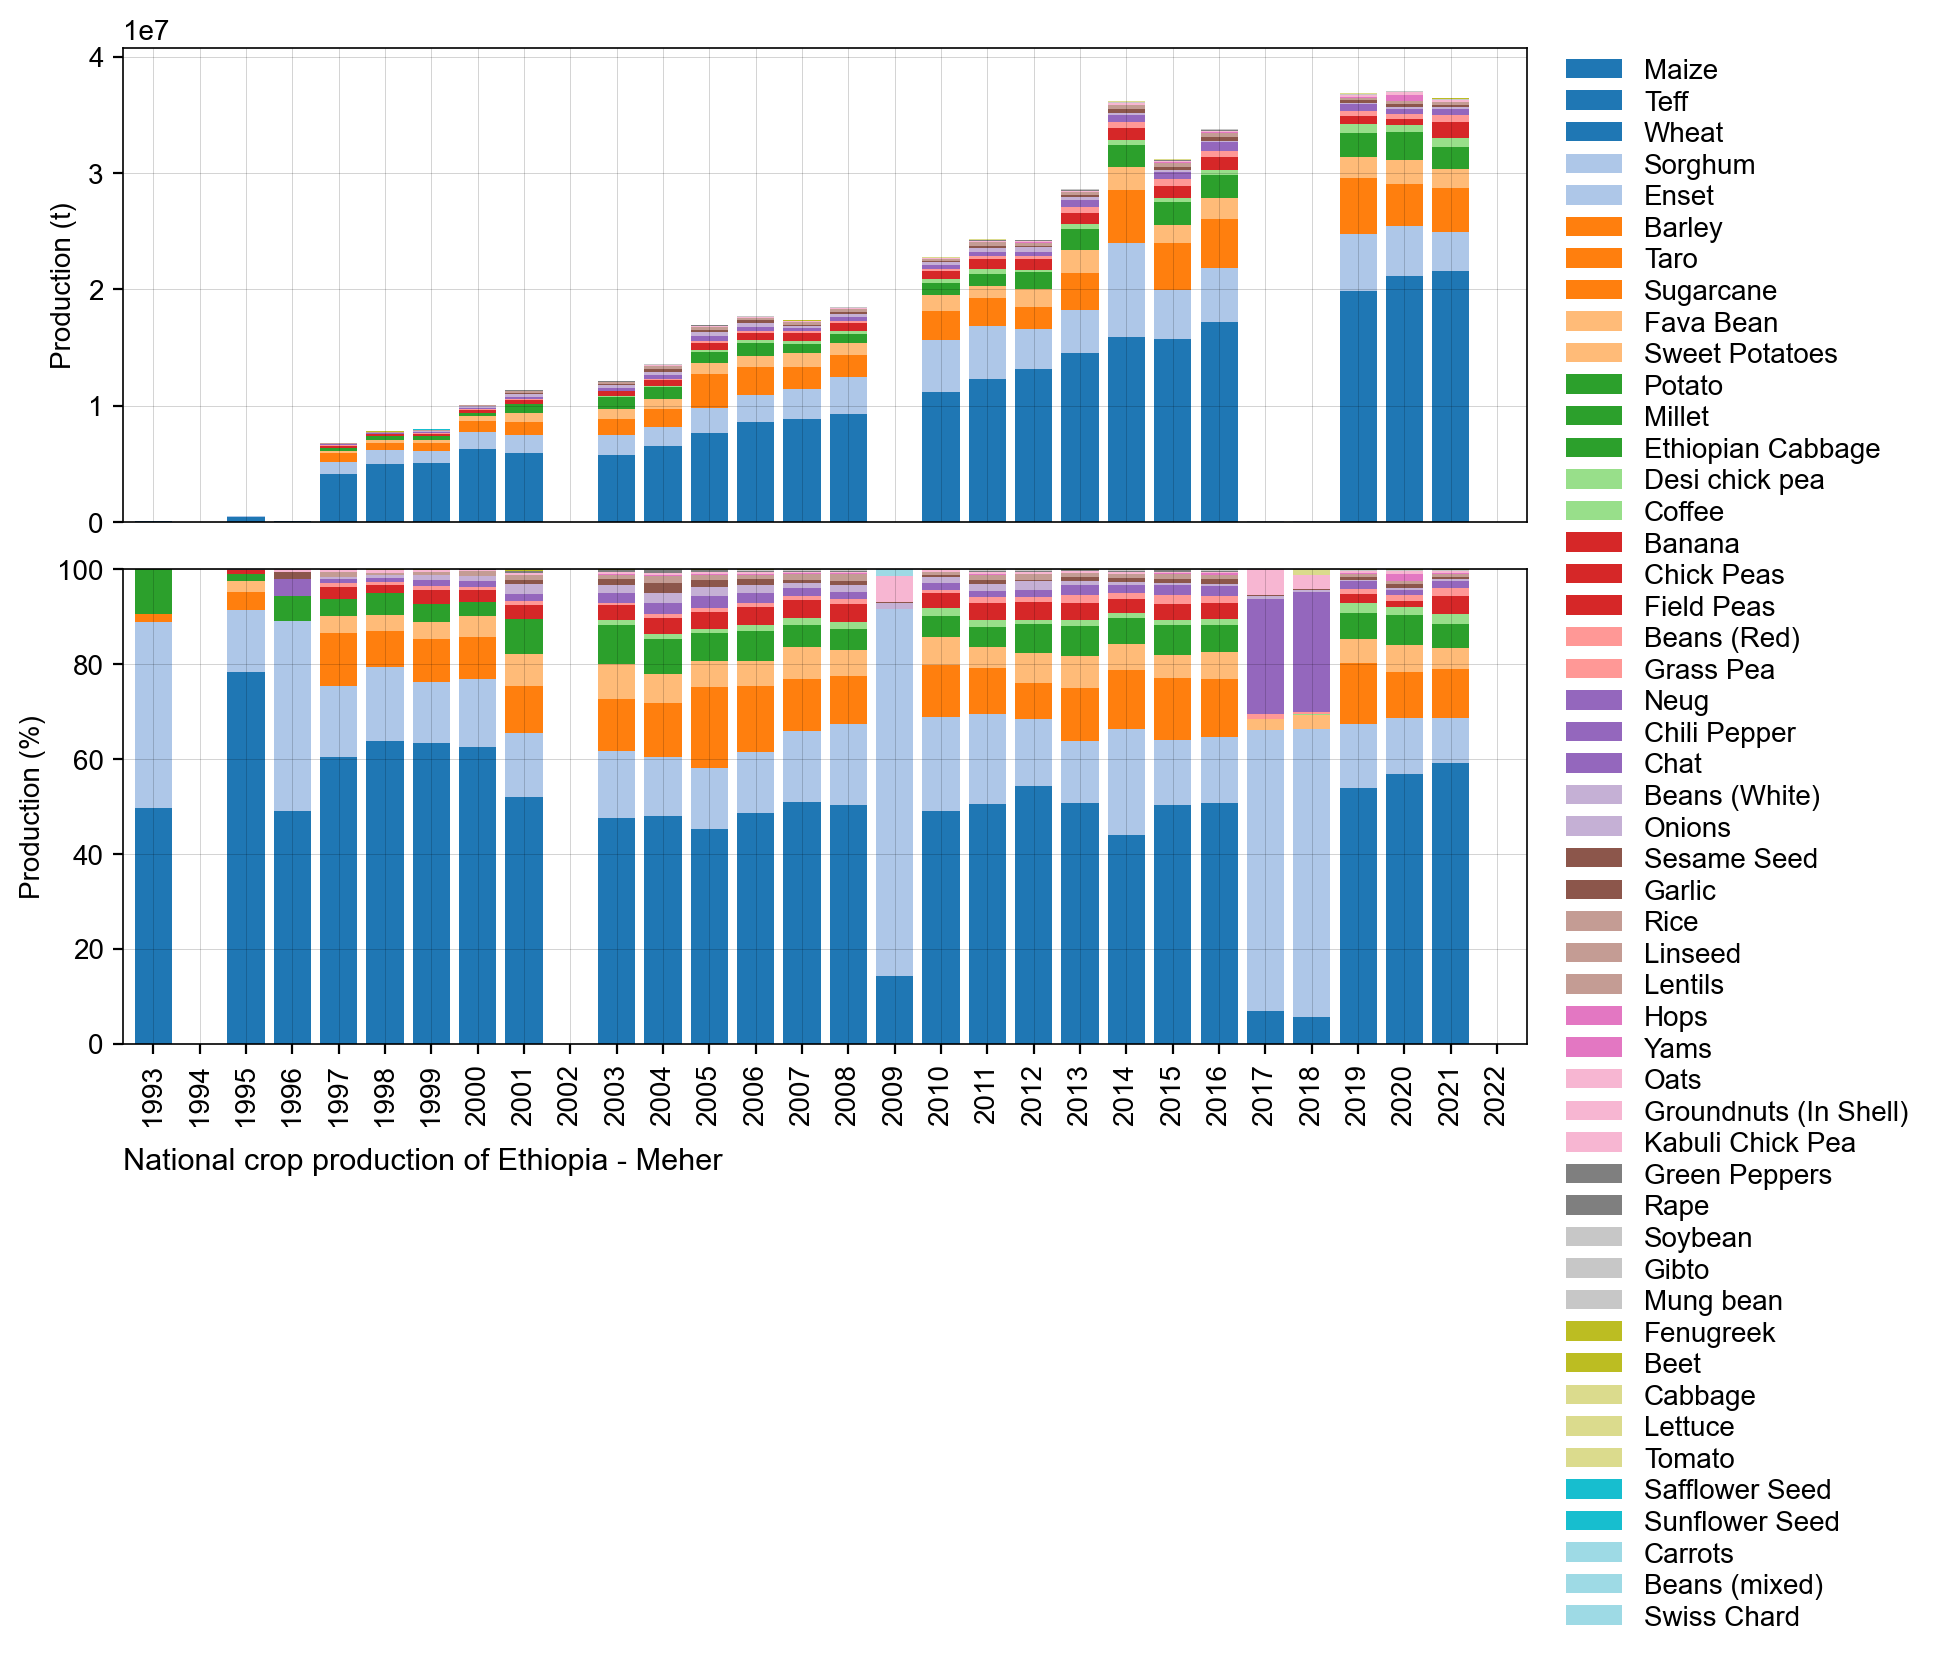

/var/folders/pv/7cvky2p95qb963ldzjhng63h0000gs/T/ipykernel_2242/2807481682.py:66: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  axes[1].grid(which='minor', axis='x', linestyle='-', color='black', visible=False)


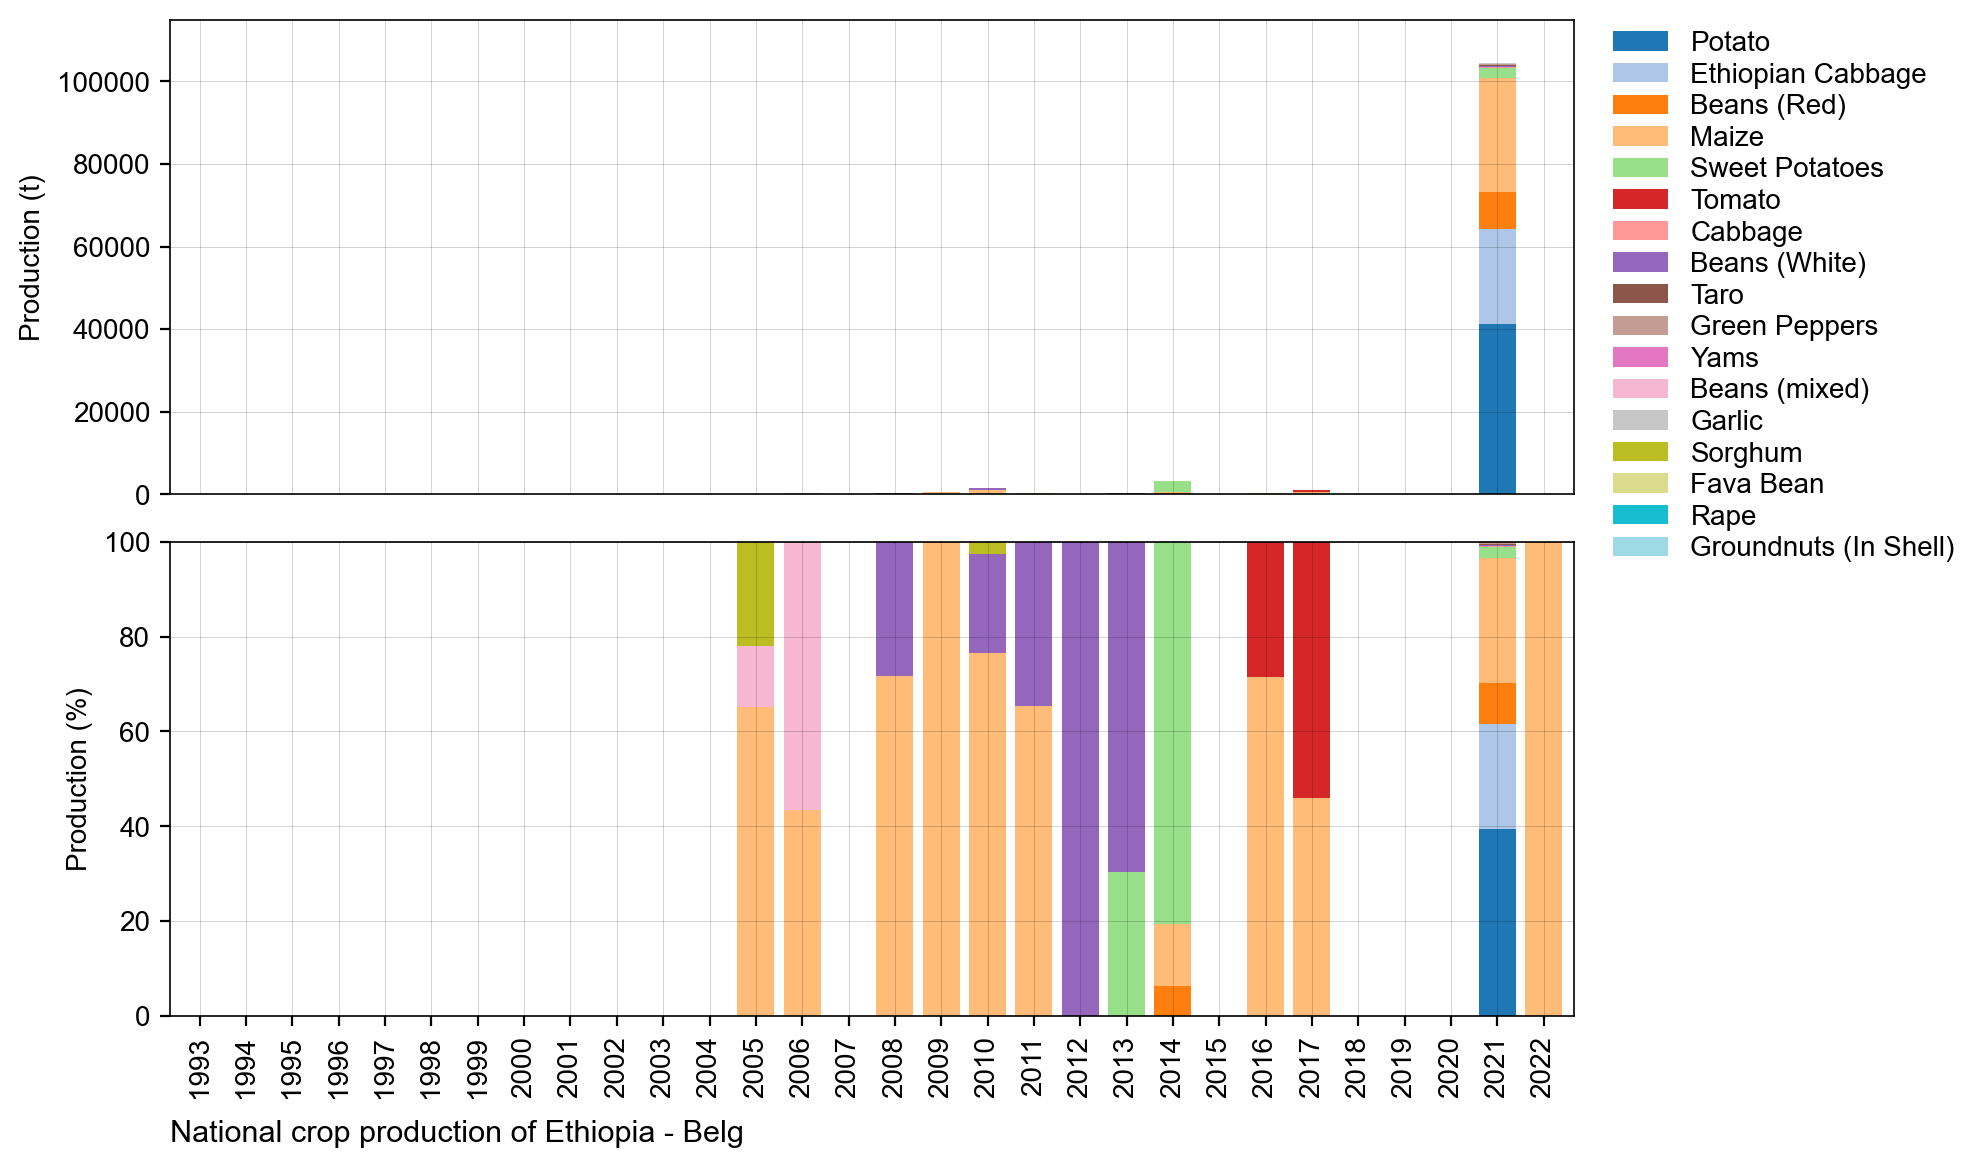

In [13]:
# Bar chart of national crop production
country_iso, country_name = 'ET', 'Ethiopia'
df = pd.read_csv('../data/crop/adm_crop_production_%s.csv' % country_iso, index_col=0)
df['year'] = df['harvest_year']
year = [df['year'].min(), df['year'].max()]
for season_name in ['Meher','Belg']:
    footnote = 'National crop production of %s - %s' % (country_name, season_name)
    fn_save = '../figures/%s_bar_natgrainprod_%s.png' % (country_iso, season_name)
    sub = df[df['season_name'] == season_name]
    PlotBarProduction(sub, year, footnote, fn_save)

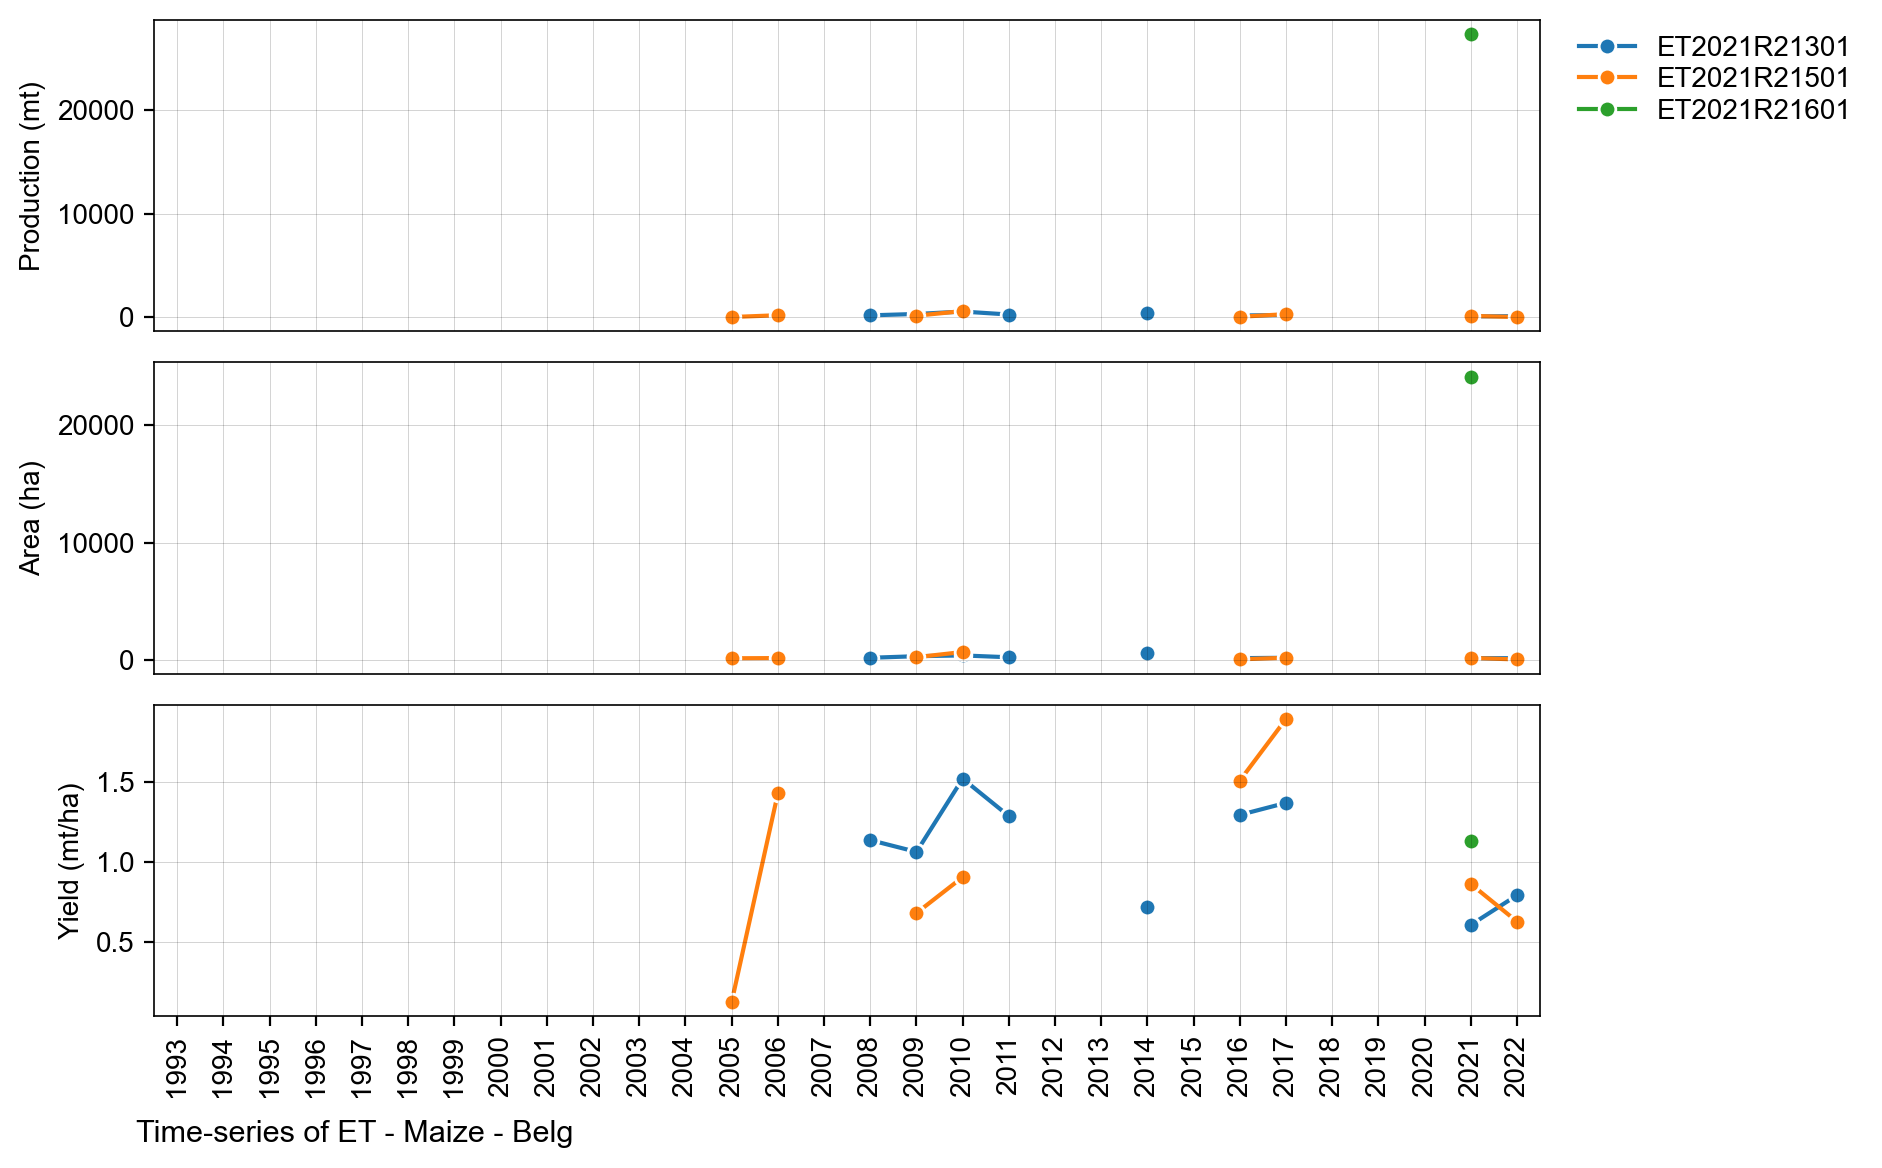

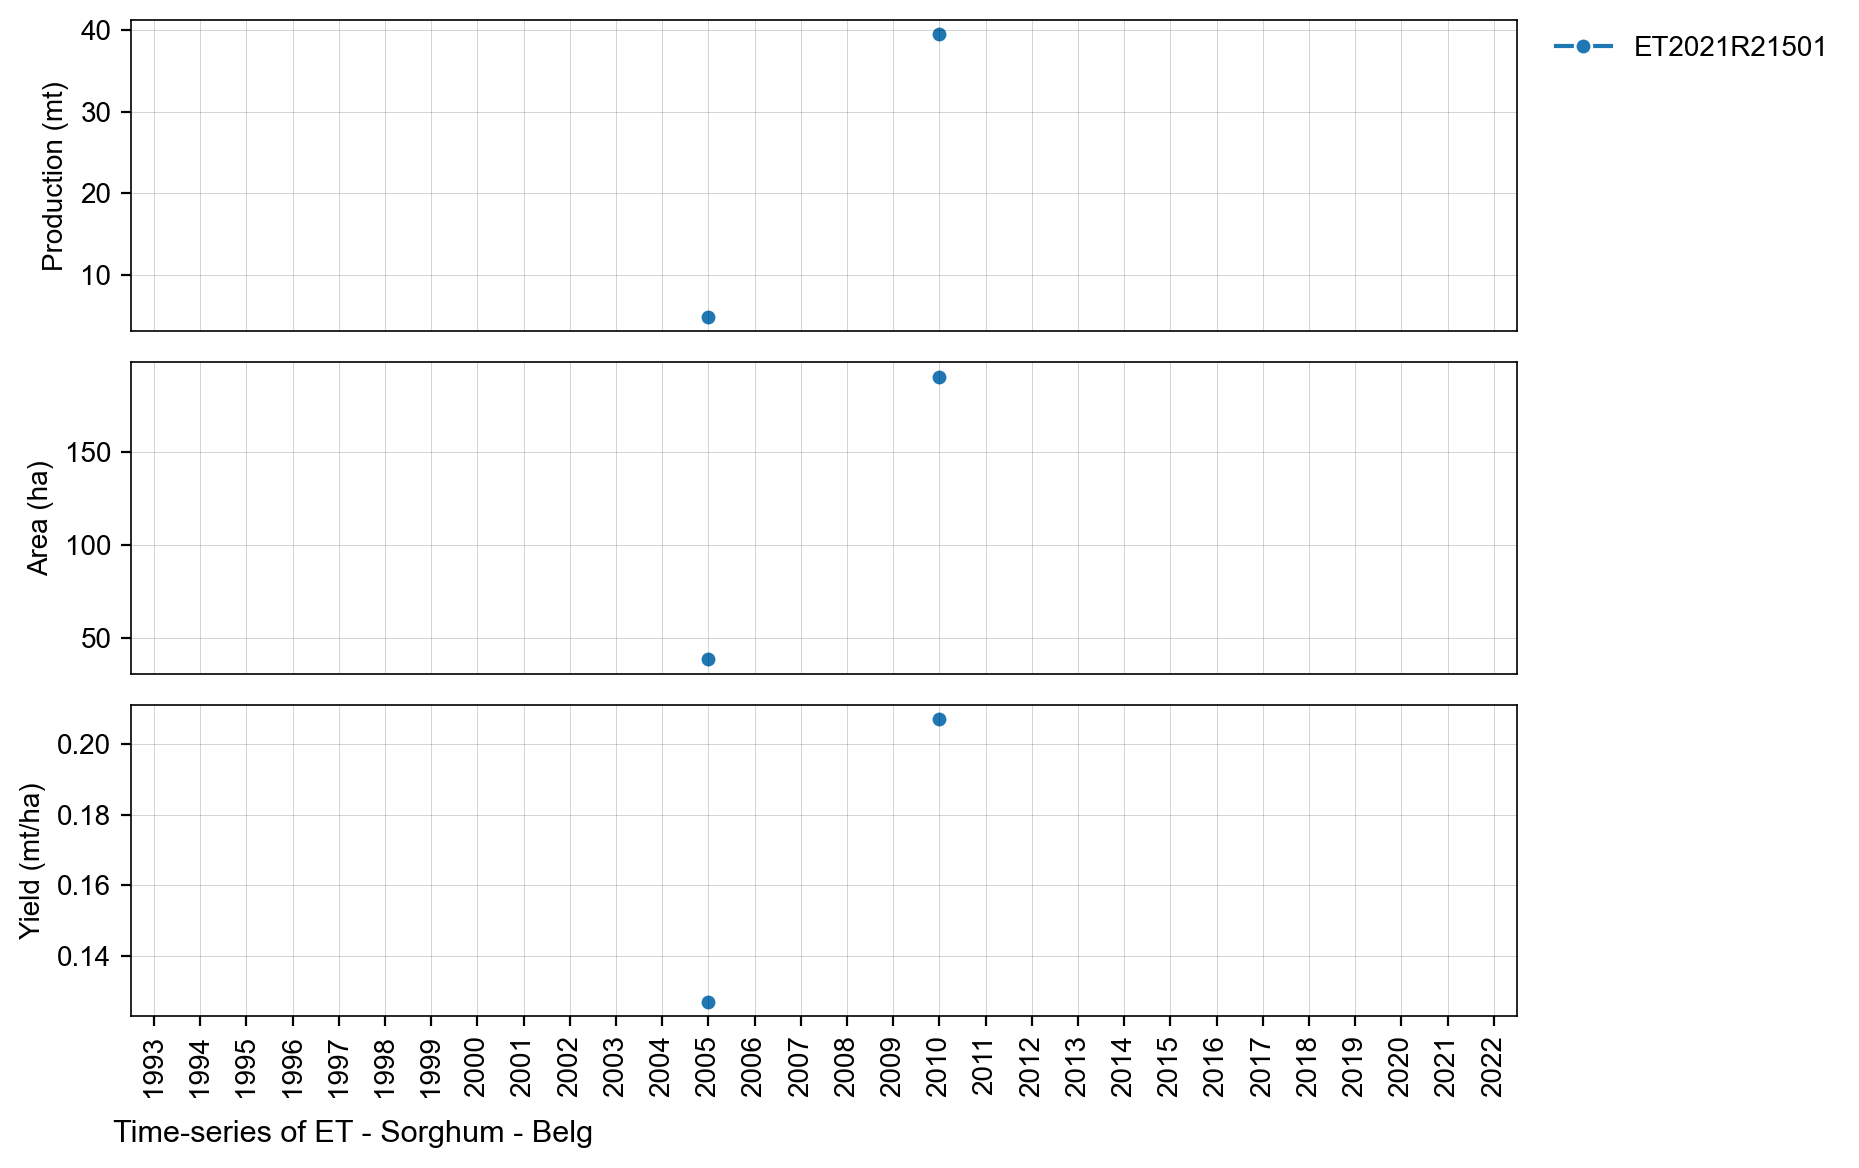

No data to plot for Time-series of ET - Wheat - Belg.


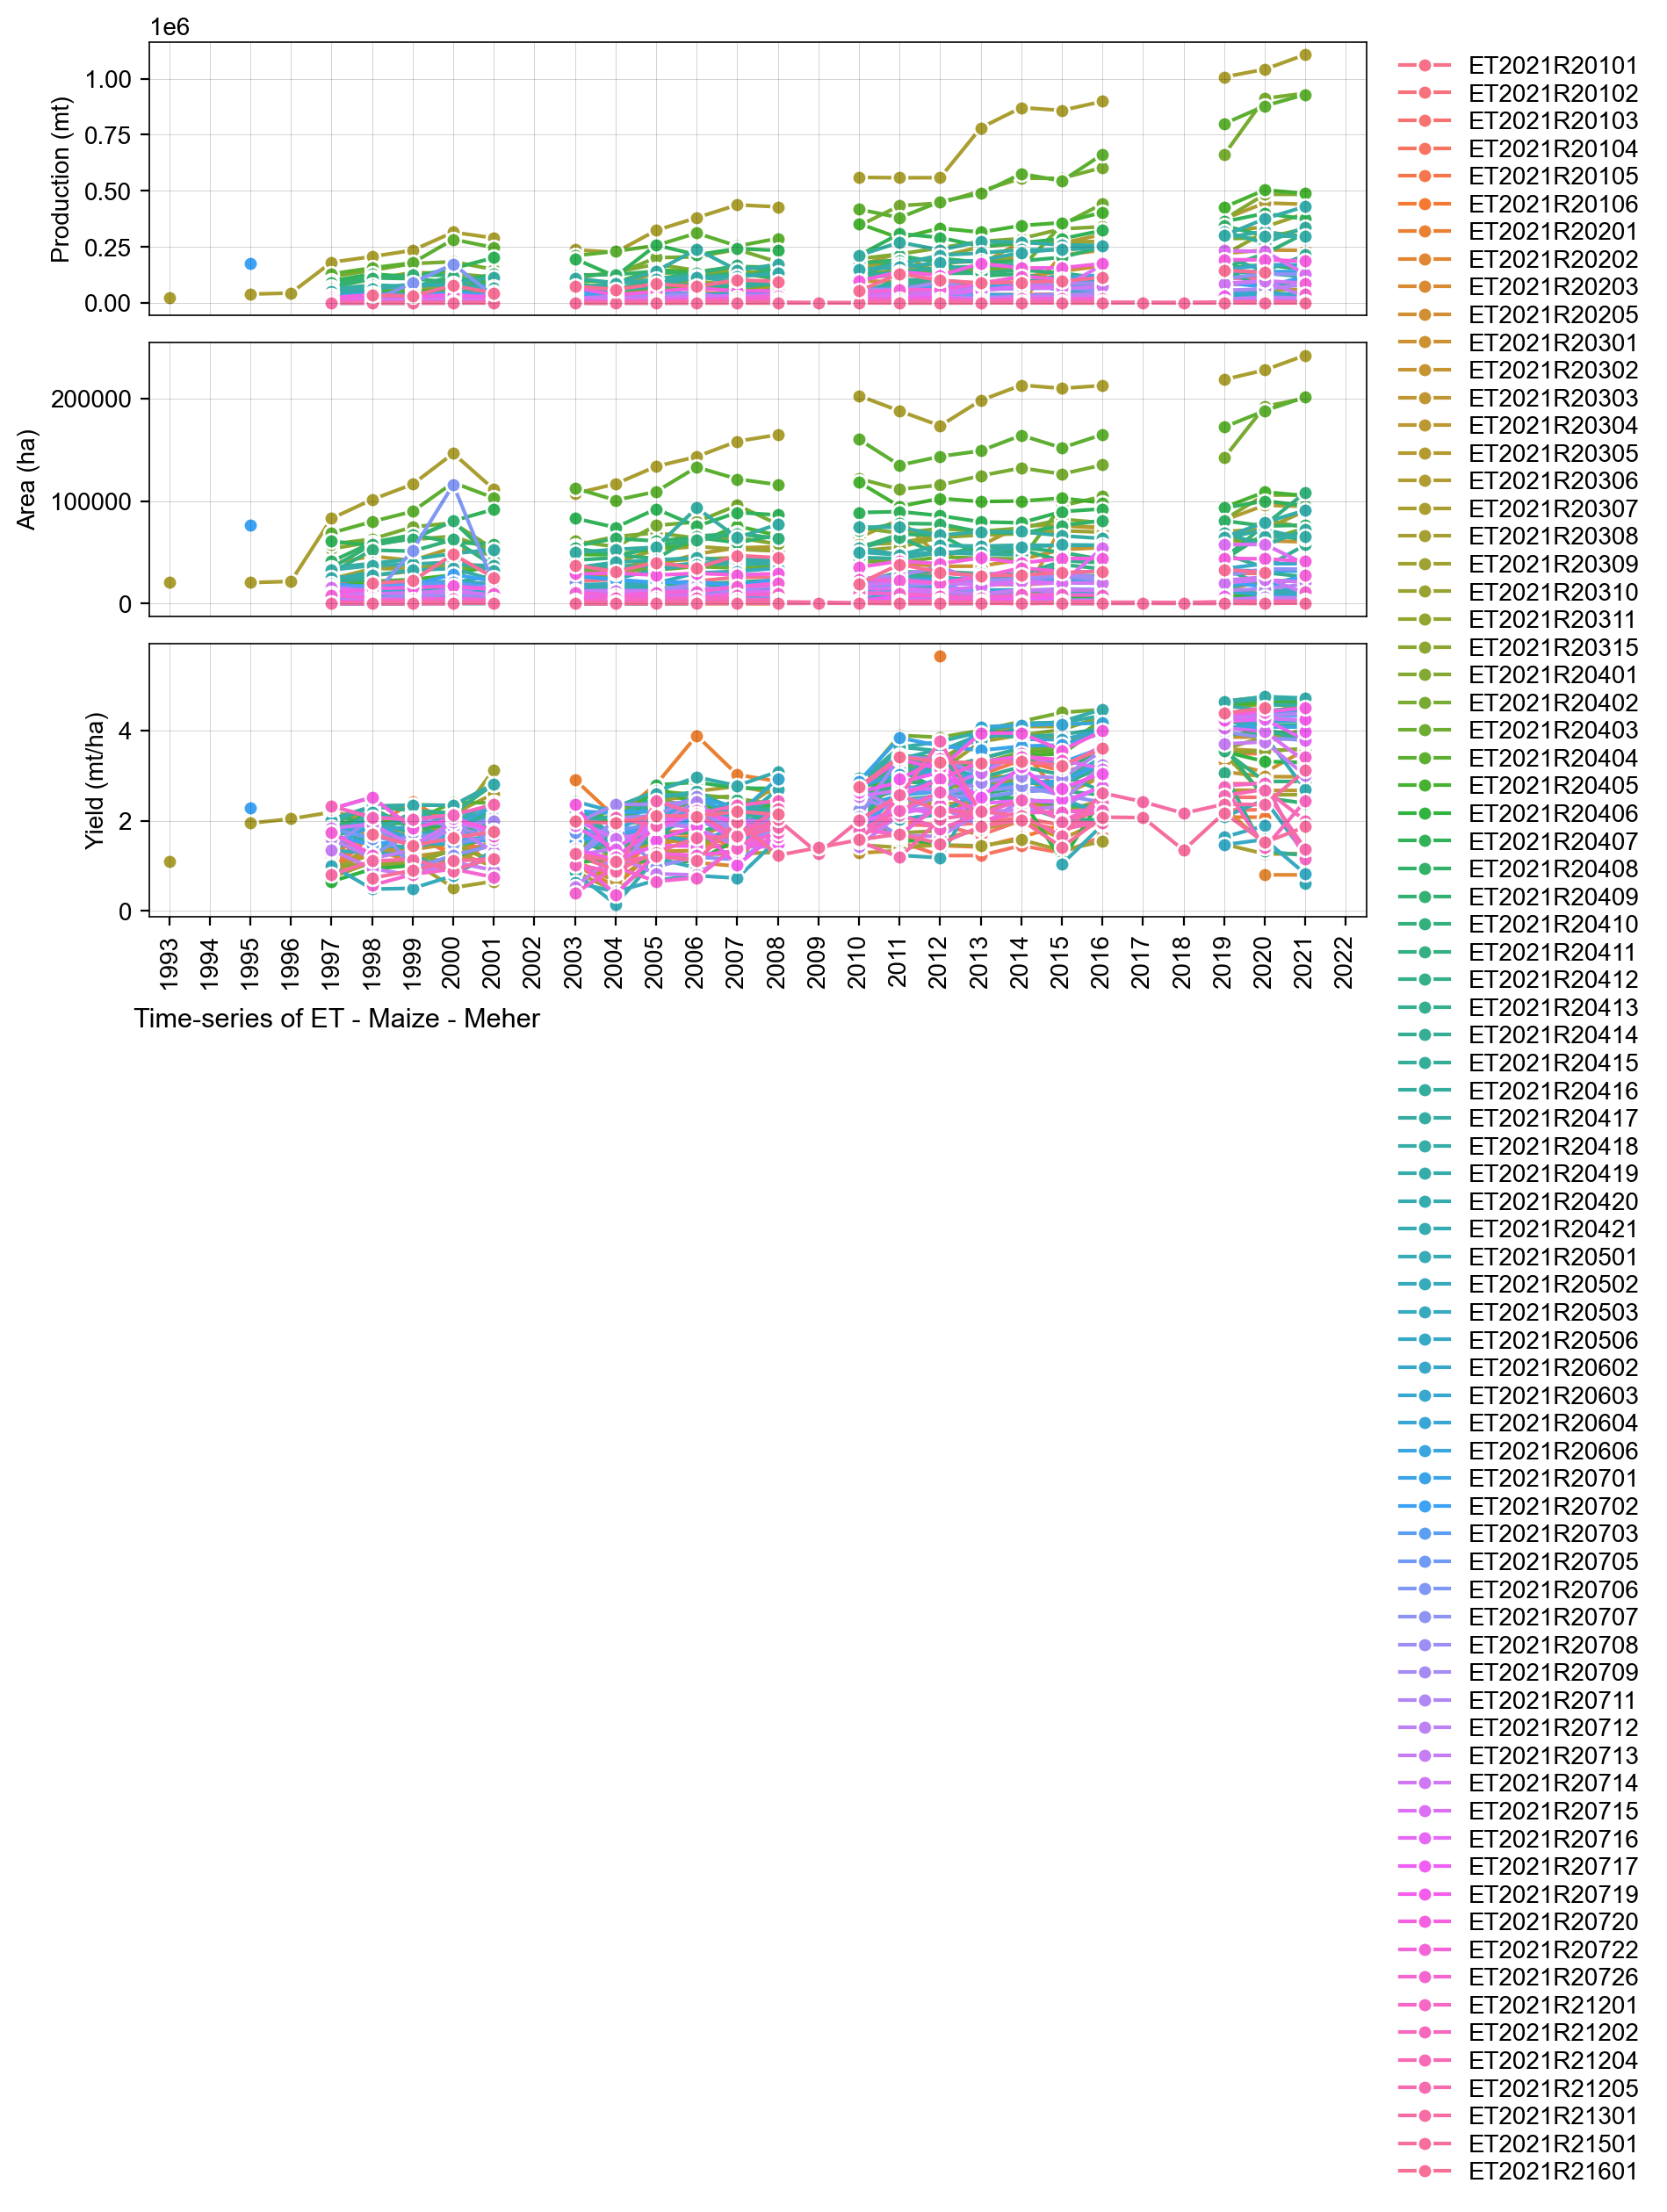

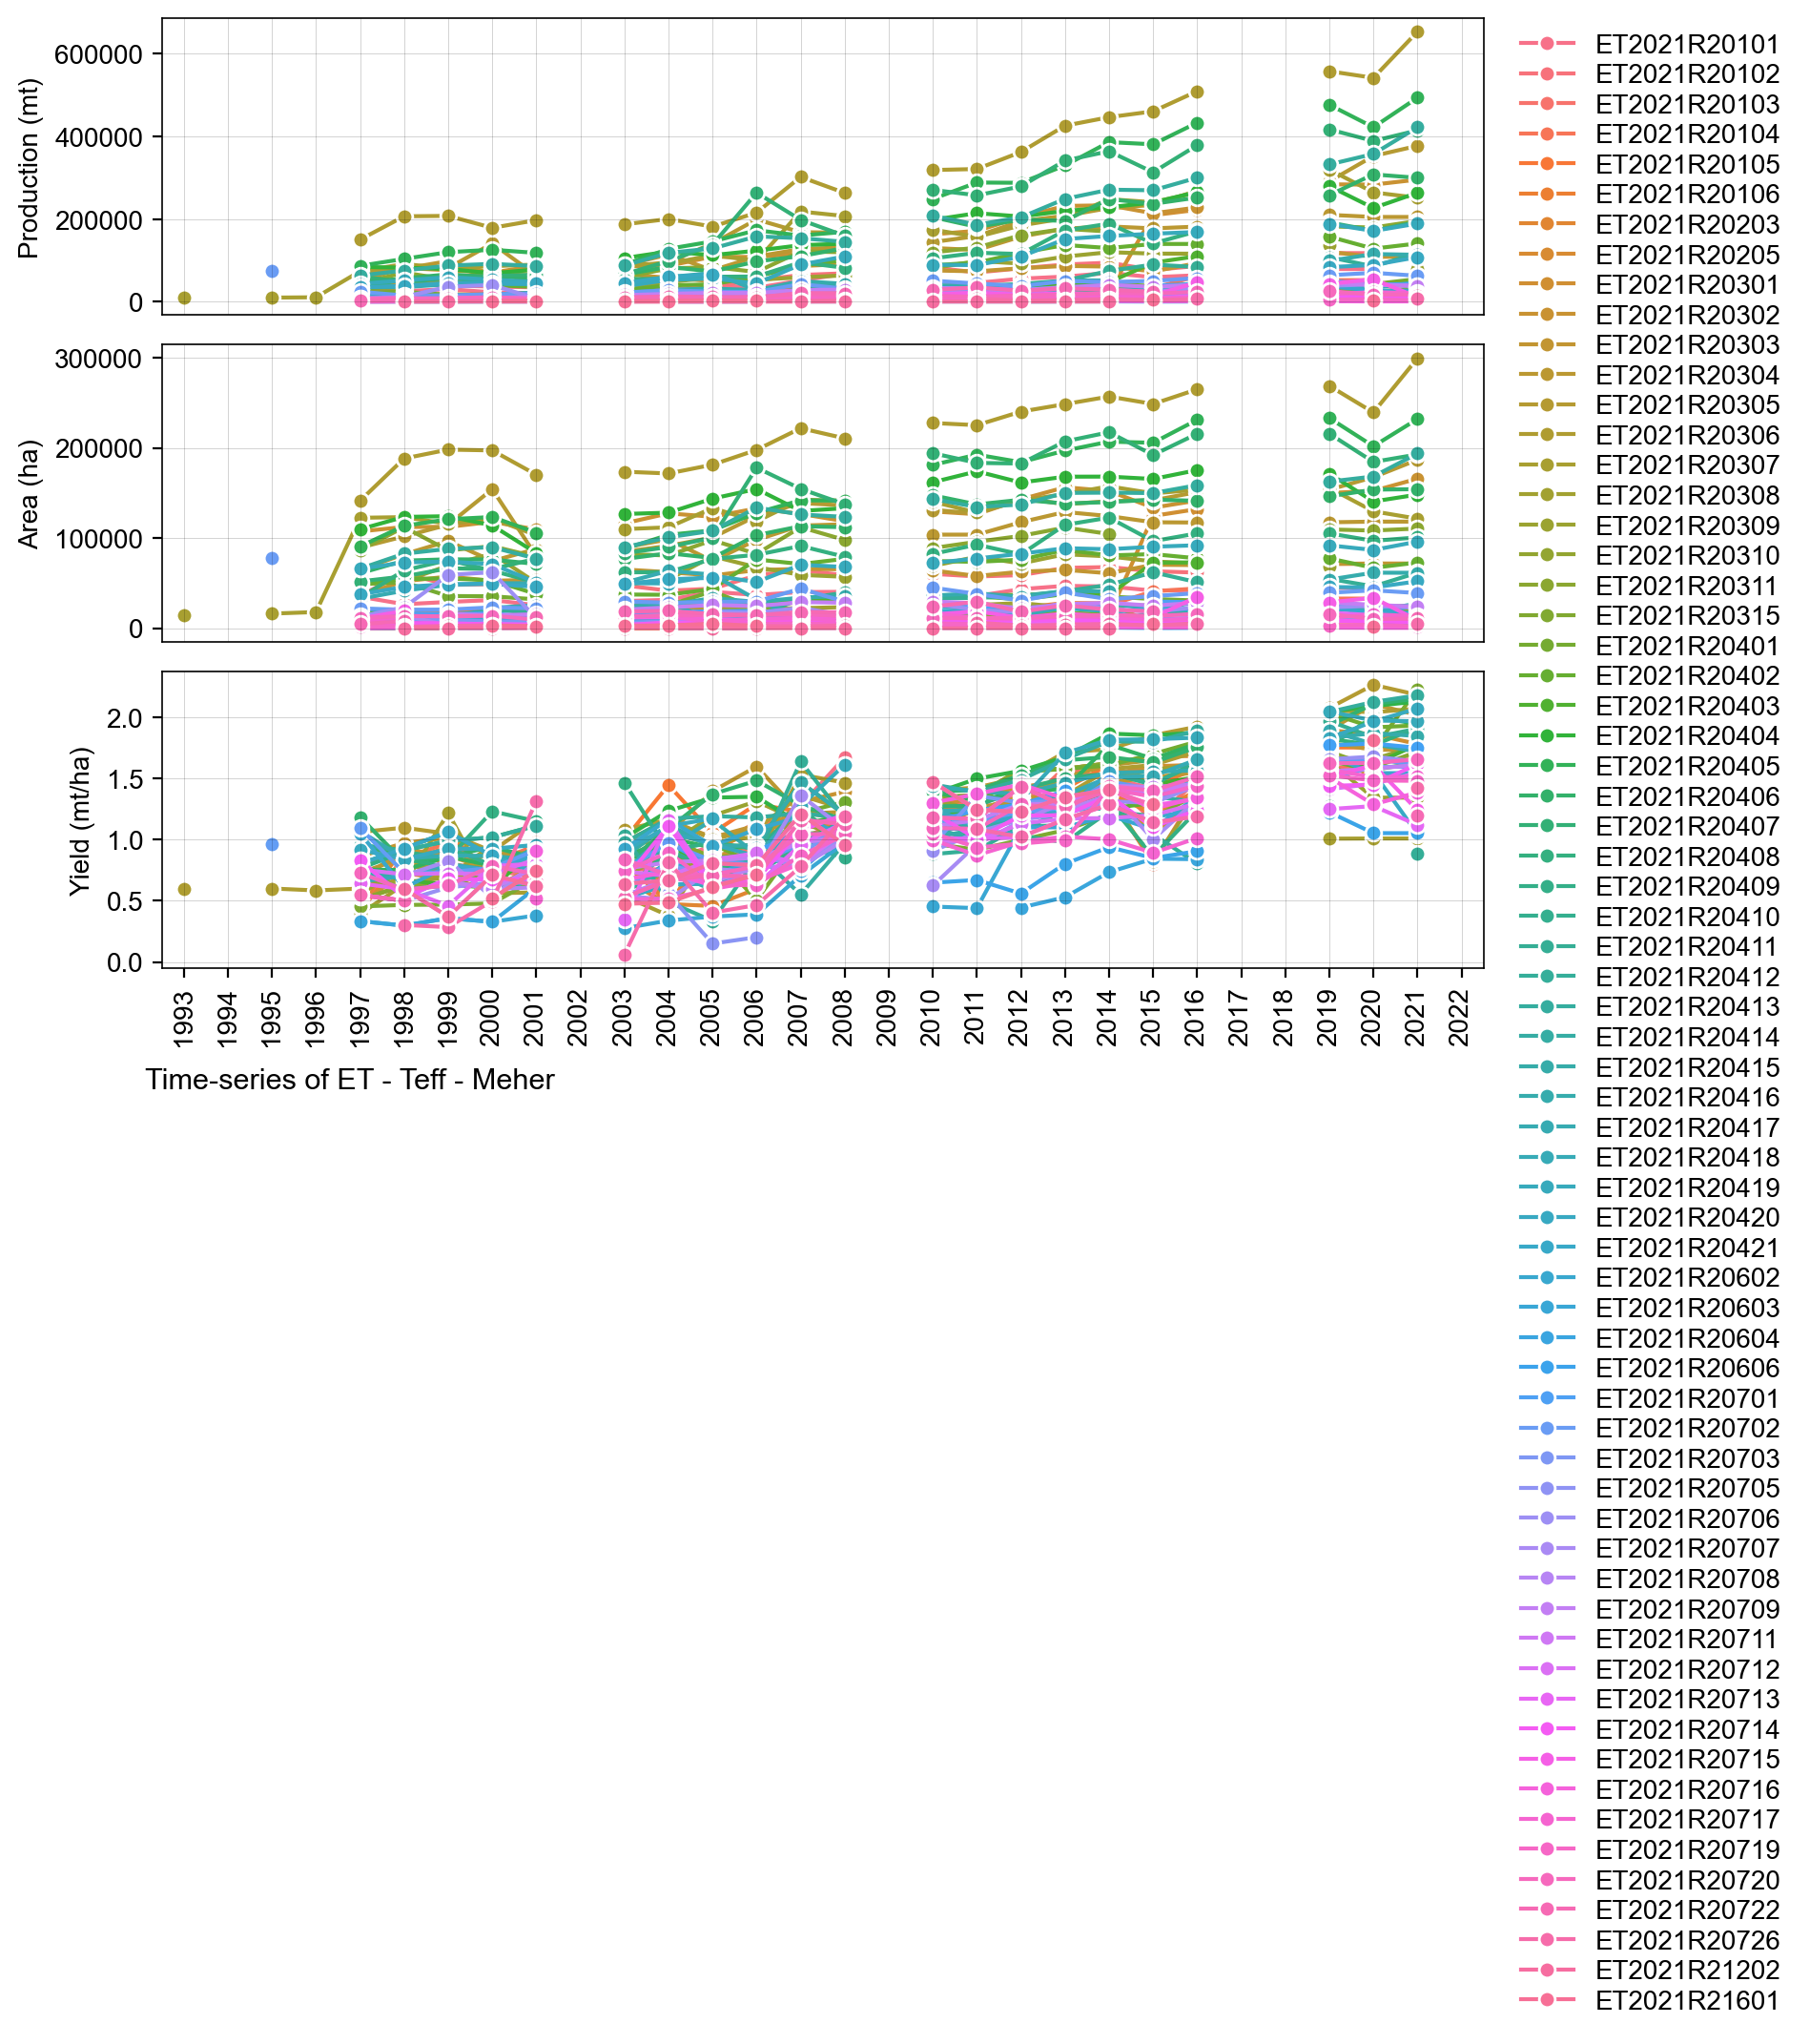

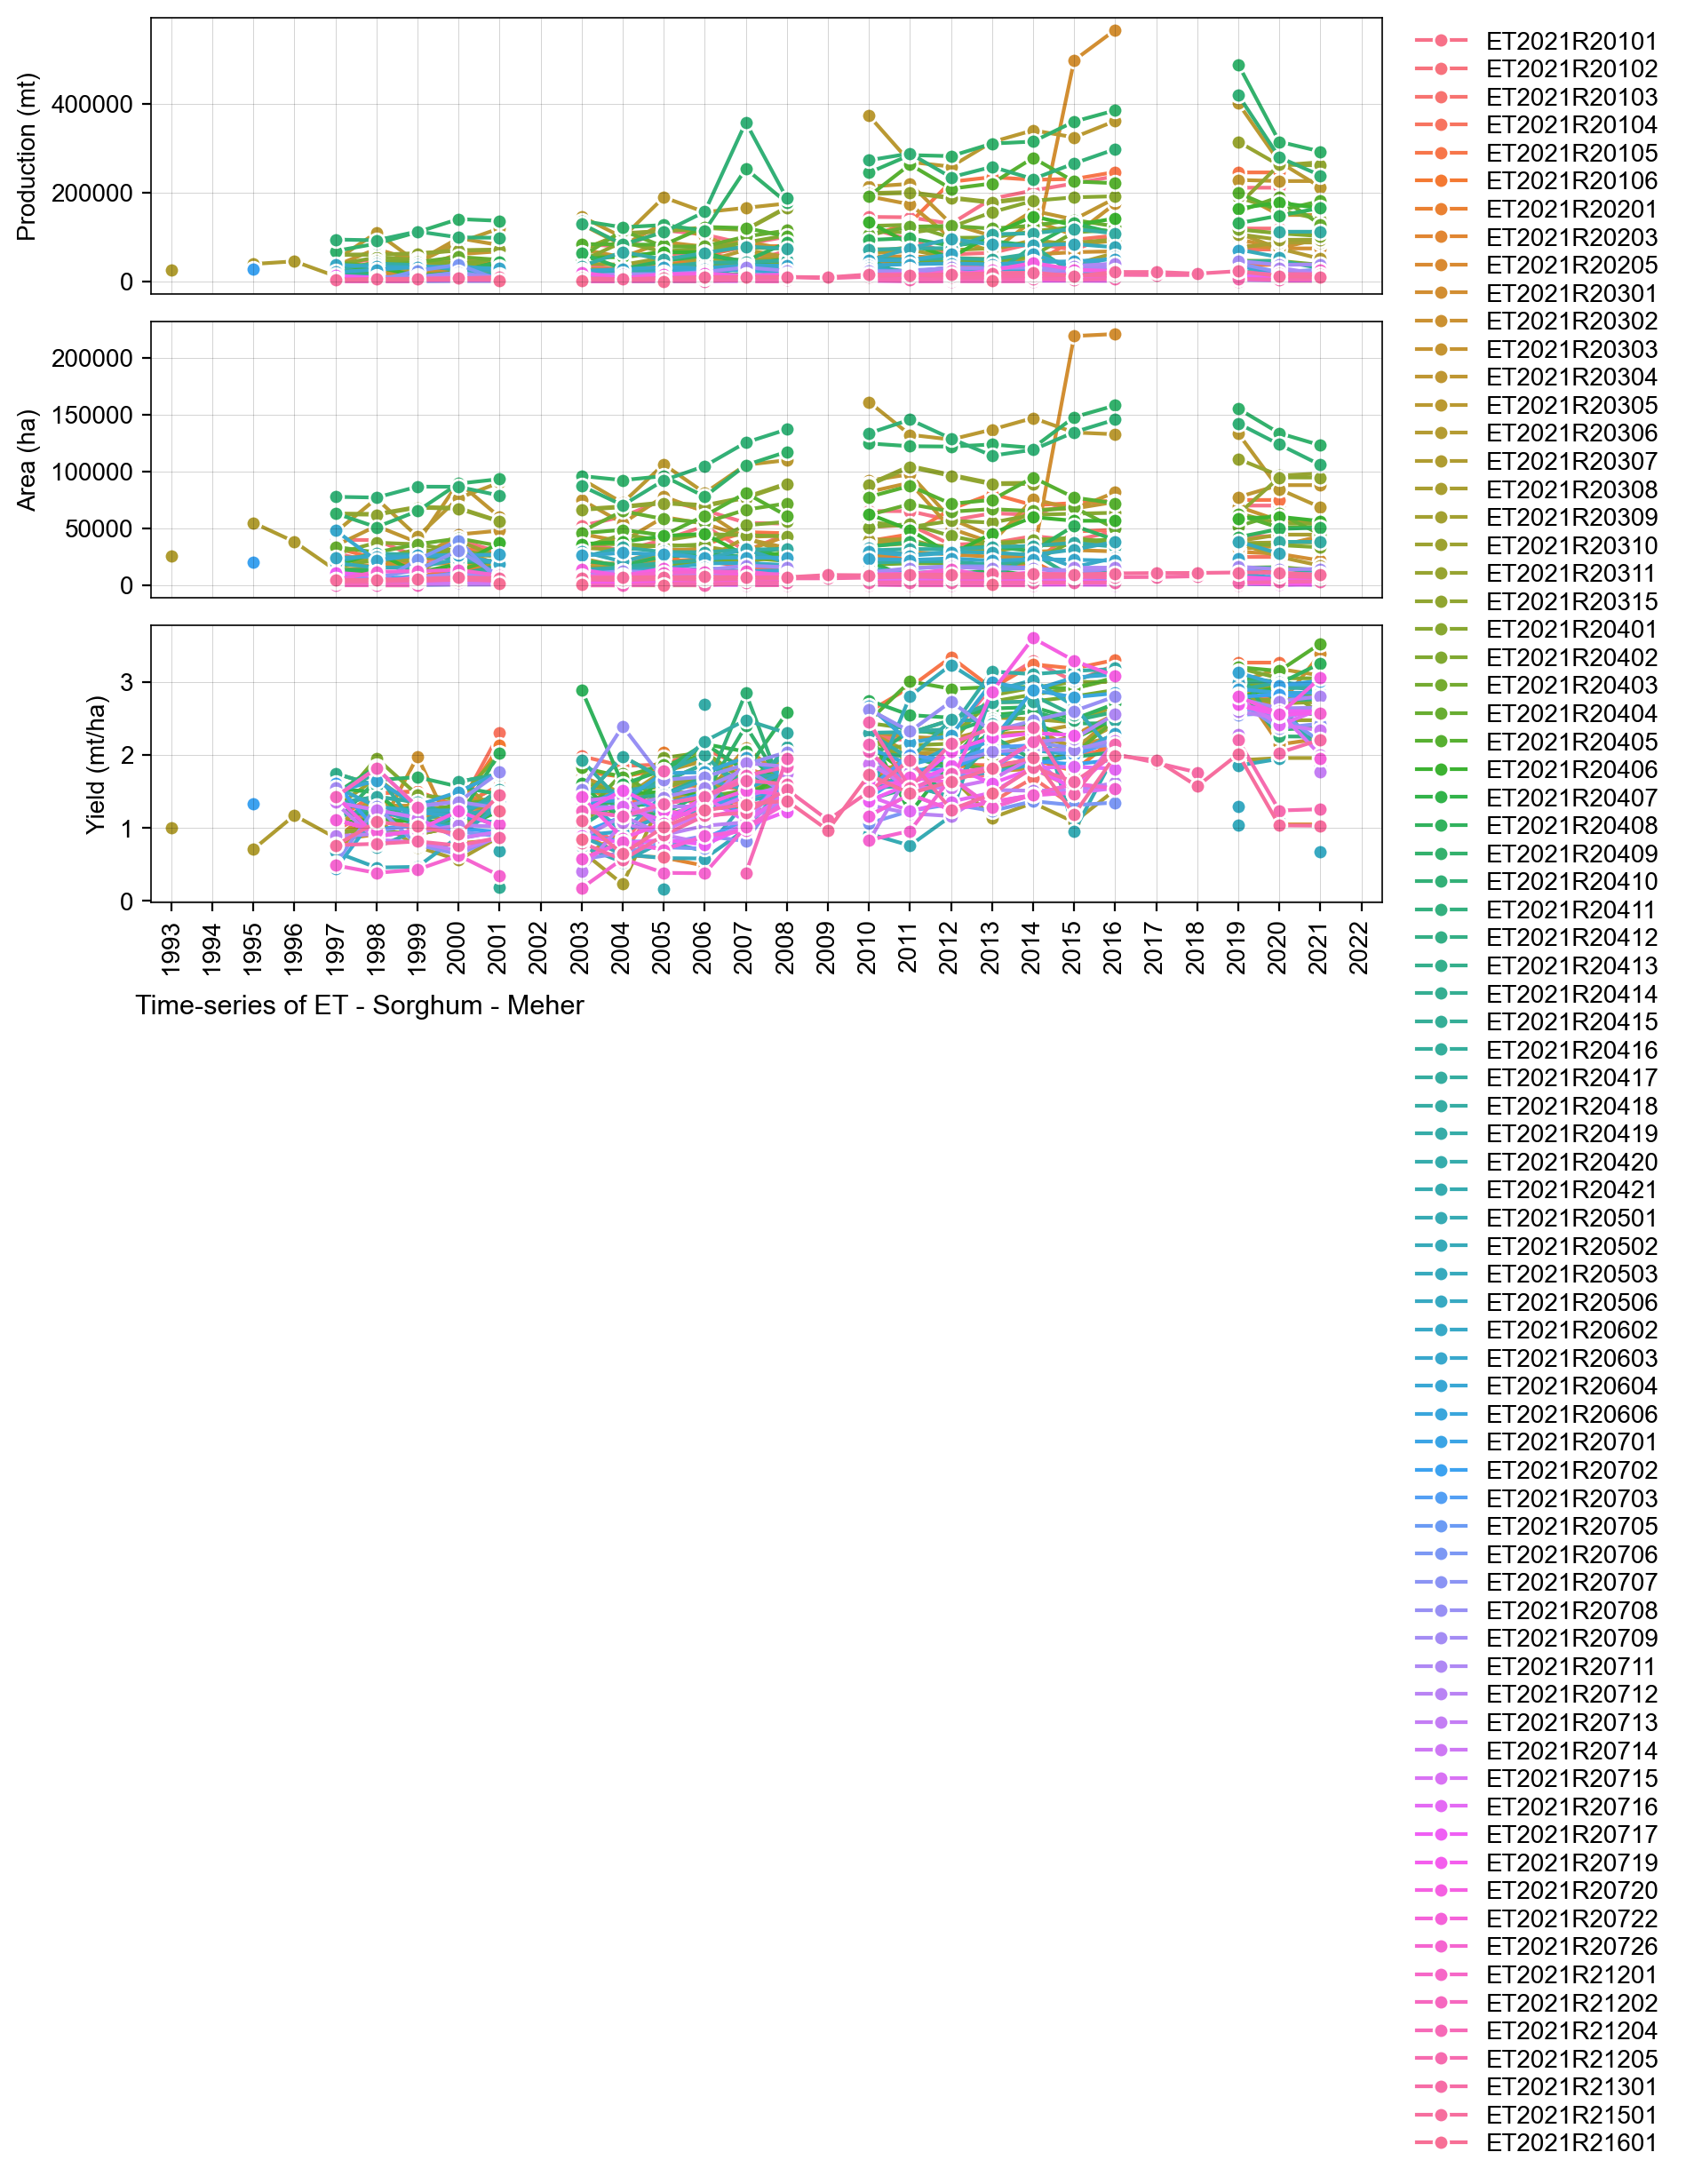

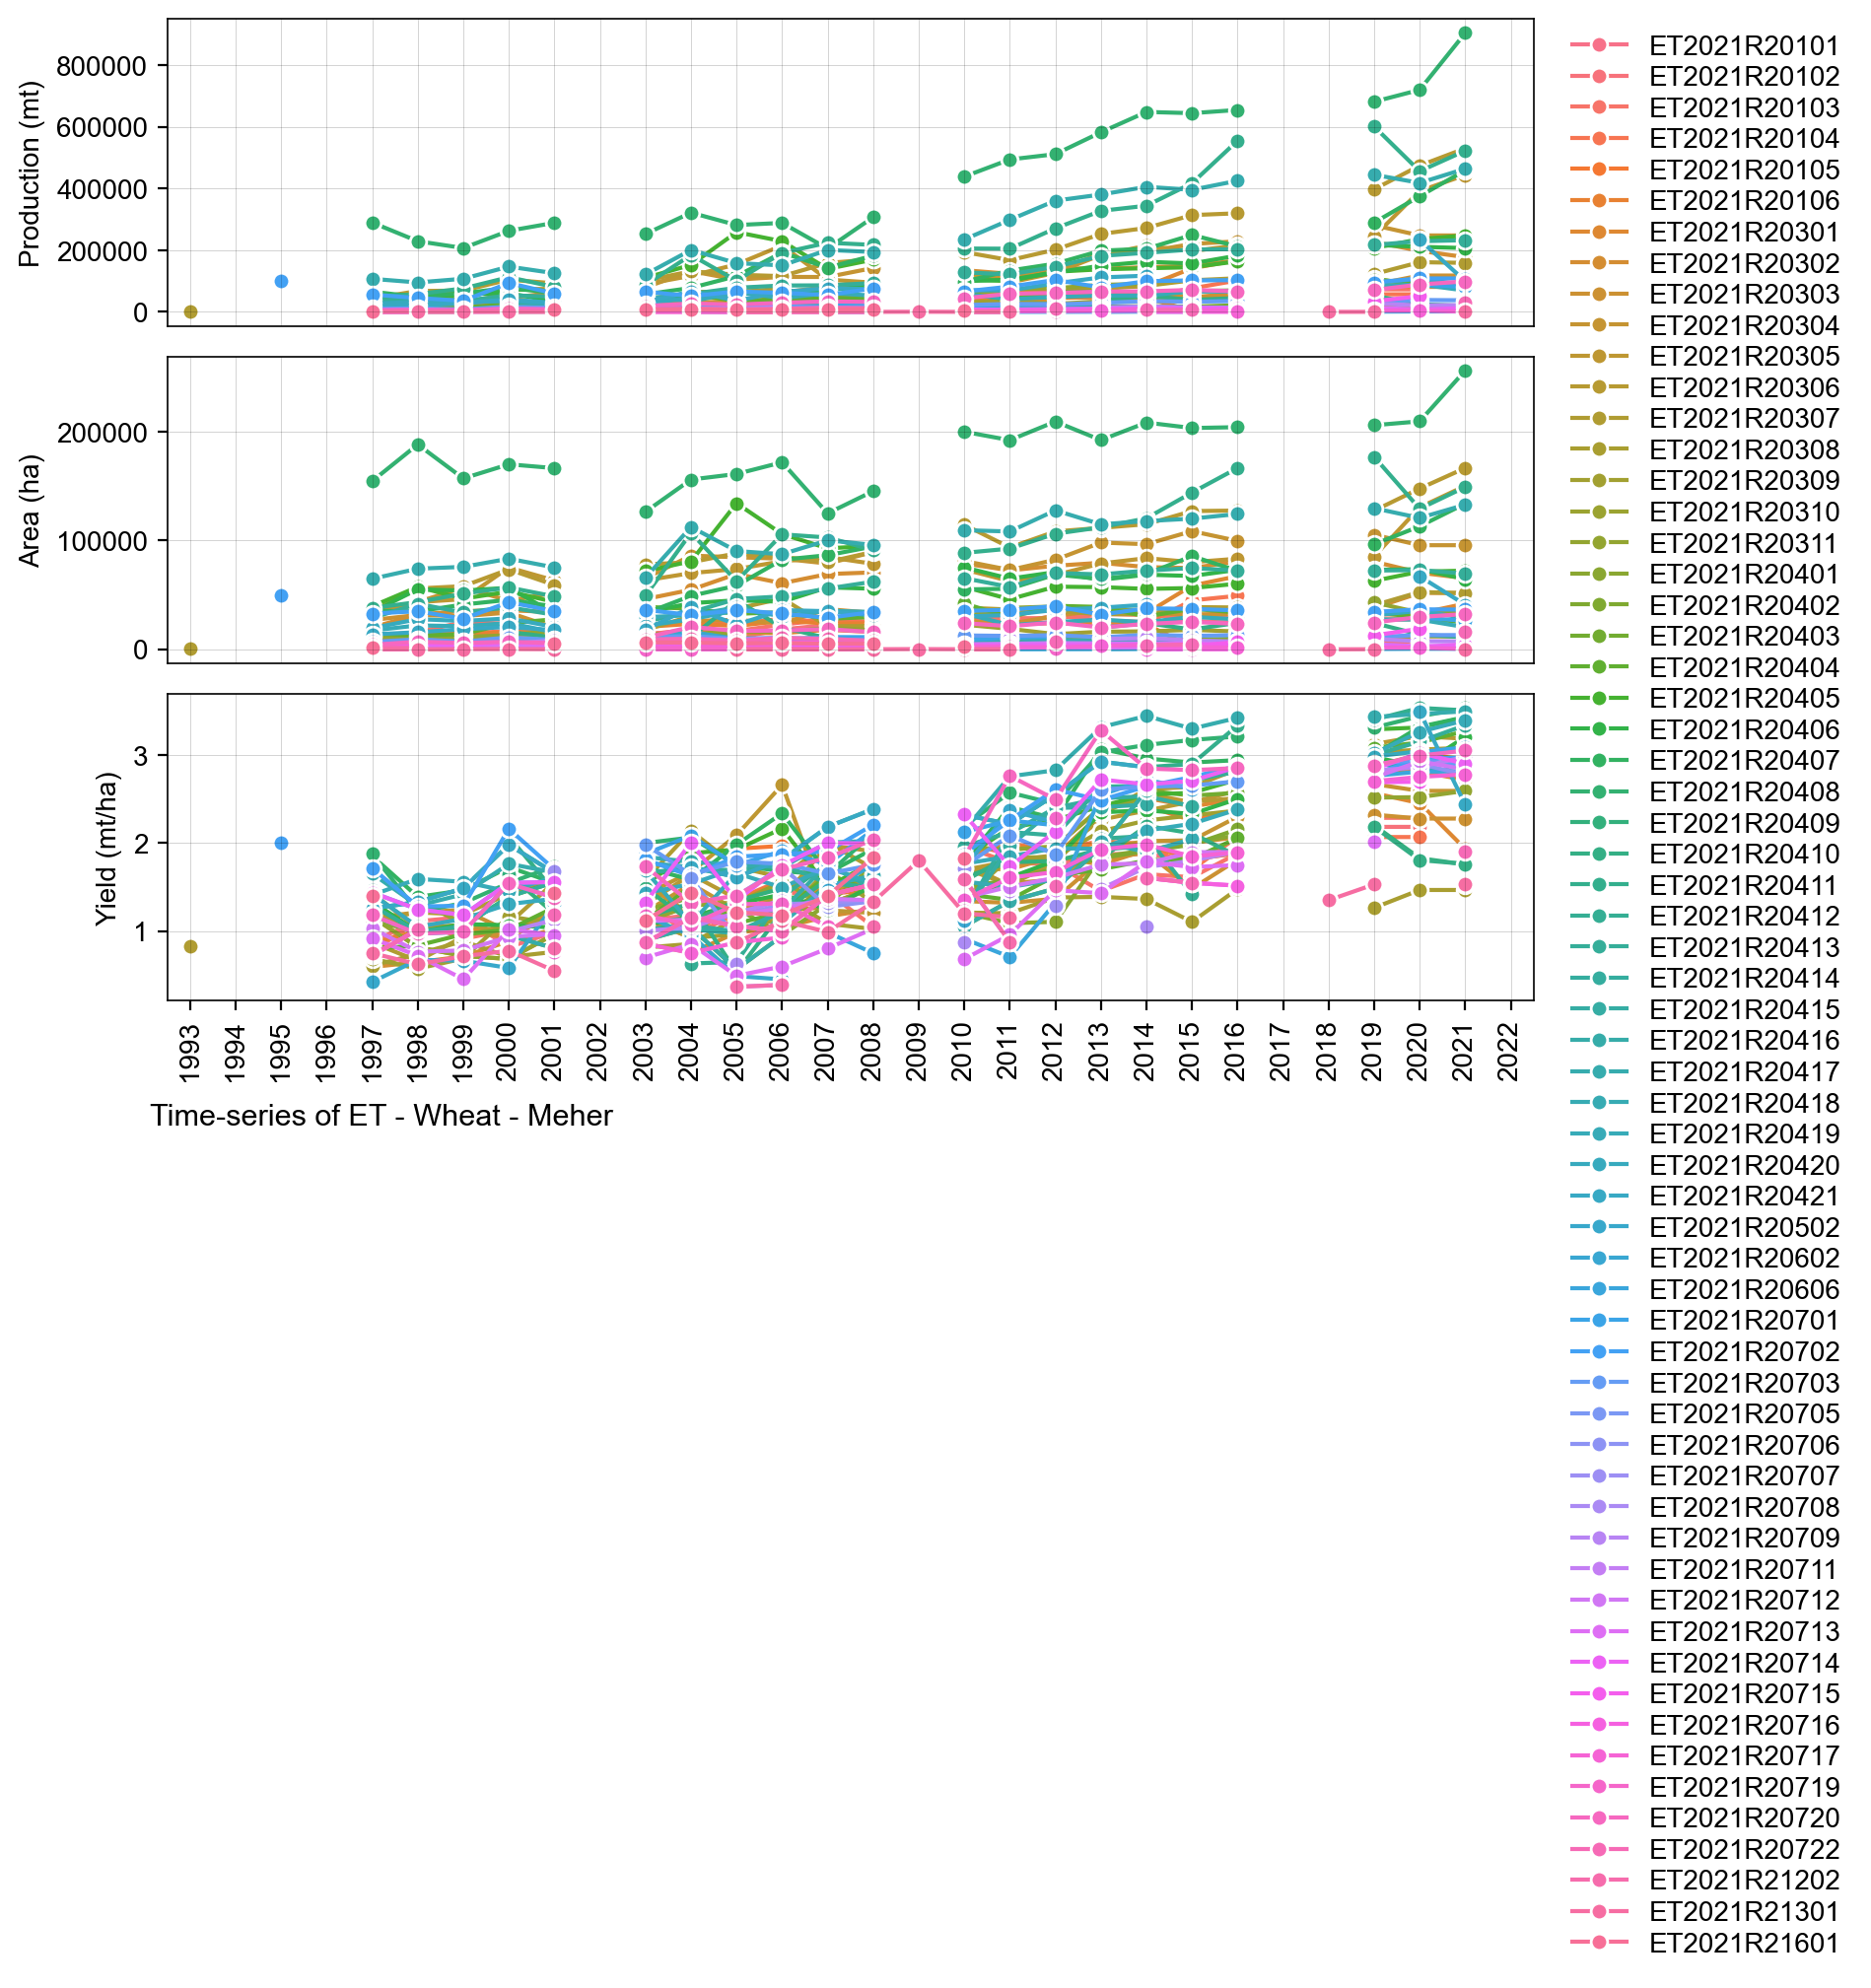

In [14]:
# Lineplot of Production-Area-Yield time-series
country_iso, country_name = 'ET', 'Ethiopia'
df = pd.read_csv('../data/crop/adm_crop_production_%s.csv' % country_iso, index_col=0)
df['year'] = df['harvest_year']
year = [df['year'].min(), df['year'].max()]
product_season = [
    ['Maize', 'Belg'],
    ['Sorghum', 'Belg'],
    ['Wheat', 'Belg'],
    ['Maize', 'Meher'],
    ['Teff', 'Meher'],
    ['Sorghum', 'Meher'],
    ['Wheat', 'Meher'],
]
for product_name, season_name in product_season:
    footnote = 'Time-series of %s - %s - %s' % (country_iso, product_name, season_name)
    fn_save = '../figures/%s_line_pay_%s_%s.png' % (country_iso, product_name, season_name)
    sub = df[(df['product'] == product_name) & (df['season_name'] == season_name)]
    PlotLinePAY(sub, year, footnote)